In [1]:
%pip install gdown
%pip install torch
%pip install torchvision
%pip install matplotlib
%pip install pandas

In [2]:
import os
import zipfile
import gdown
import shutil
import glob
import torch
import torchvision
import numpy as np
from collections import Counter
from PIL import Image
import random
import matplotlib.pyplot as plt
from torchvision.ops import box_convert
import matplotlib.patches as patches
import pandas as pd
from torch.utils.data import WeightedRandomSampler

In [3]:
random.seed(42)

In [4]:
data_dir = os.path.join(os.getcwd(), "data")

def descargar_dataset(data_dir):

  # Verificar si exsite la carpeta
  if not os.path.exists(data_dir):

    try:
      # Nombre del archivo ZIP que se va a guardar
      ZIP_NAME = "kaggle-xray_baggage_scanner_anomaly_detection.zip"
      zip_path = os.path.join(data_dir, ZIP_NAME)

      # Crear carpeta data
      os.makedirs(data_dir, exist_ok=True)

      # Descargar el ZIP
      print("Descargando archivo zip ...")
      # Lo tomamos de Google Drive porque Kaggle requeire autenticación
      gdown.download(id="1IqPblTm7nmKFpHXtl4beopE_SajTBoI0", output=zip_path, quiet=False)
      print("Archivo zip descargado.")

      # Descomprimir el ZIP
      print("Descomprimiendo archivo ...")
      with zipfile.ZipFile(zip_path, "r") as zf:
          zf.extractall(data_dir)
      print("Archivo descomprimido.")
    except:
      # En caso de error, eliminar la carpeta creada
      shutil.rmtree(data_dir, ignore_errors=True)
      print("Ocurrió un error al descargar el dataset.")

  print(f"Dataset descargado en: '{data_dir}'")


# Descargar el dataset (solo si no existe la carpeta data)
descargar_dataset(data_dir)

Descargando archivo zip ...


Downloading...
From (original): https://drive.google.com/uc?id=1IqPblTm7nmKFpHXtl4beopE_SajTBoI0
From (redirected): https://drive.google.com/uc?id=1IqPblTm7nmKFpHXtl4beopE_SajTBoI0&confirm=t&uuid=64911a63-bf8a-4cdd-9160-2d48dcef60bc
To: /content/data/kaggle-xray_baggage_scanner_anomaly_detection.zip
100%|██████████| 140M/140M [00:02<00:00, 65.2MB/s]


Archivo zip descargado.
Descomprimiendo archivo ...
Archivo descomprimido.
Dataset descargado en: '/content/data'


In [5]:
%pip install pillow numpy matplotlib --quiet

In [6]:
# ============================================================================================
# Baseline — torchvision + Faster R-CNN (ResNet50-FPN) sobre dataset en formato YOLO
# ============================================================================================

# ---------------------------------------
# 0) Dependencias (instalar si hiciera falta)
# ---------------------------------------
# !pip install torch torchvision torchaudio --upgrade --quiet
# !pip install pillow numpy matplotlib --quiet

# ---------------------------------------
# 1) Imports y configuración
# ---------------------------------------
import os, glob, random, time, math
from typing import List, Dict, Tuple

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.ops import box_convert, box_iou
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as T

# Reproducibilidad mínima
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [7]:
# ---------------------------------------
# 2) Configuración de rutas y clases
# ---------------------------------------
DATA_DIR = data_dir

# Clases (según tu enunciado)
CLASS_NAMES = ["Tijera", "Navaja", "Cuchillo", "Cutter", "Navaja multiuso"]
NUM_CLASSES = len(CLASS_NAMES)  # 5
NUM_CLASSES_WITH_BG = NUM_CLASSES + 1  # +1 background para Faster R-CNN

# Paths estándar (YOLO-style)
SPLITS = {
    "train": {"images": os.path.join(DATA_DIR, "train", "images"),
              "labels": os.path.join(DATA_DIR, "train", "labels")},
    "valid": {"images": os.path.join(DATA_DIR, "valid", "images"),
              "labels": os.path.join(DATA_DIR, "valid", "labels")},
    "test":  {"images": os.path.join(DATA_DIR, "test",  "images"),
              "labels": os.path.join(DATA_DIR, "test",  "labels")},
}

In [8]:
# ---------------------------------------
# 3) Dataset: YOLO -> torchvision detection
#    - Lee .txt YOLO (cx,cy,w,h normalizado) y convierte a xyxy en píxeles
#    - IMPORTANTE: labels +1 para fondo=0 (Faster R-CNN)
# ---------------------------------------
class YoloDetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images = sorted(glob.glob(os.path.join(images_dir, "*")))
        self.labels_dir = labels_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def _read_yolo_txt(self, label_path):
        boxes_cxcywh = []
        labels = []
        if not os.path.exists(label_path):
            # Si no existe el .txt, interpretamos como imagen sin objetos
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        with open(label_path, "r") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]
        if not lines:
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        for ln in lines:
            parts = ln.split()
            if len(parts) != 5:
                # Línea malformada -> ignorar o levantar error; aquí ignoramos
                # (podrías loguear el archivo para depurar si aparece)
                continue
            c, cx, cy, w, h = parts
            labels.append(int(c))
            boxes_cxcywh.append([float(cx), float(cy), float(w), float(h)])
        if len(boxes_cxcywh) == 0:
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        return torch.tensor(boxes_cxcywh, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(self.labels_dir, base + ".txt")
        boxes_cxcywh_norm, labels0 = self._read_yolo_txt(lbl_path)

        # Desnormalizar y convertir a xyxy en píxeles
        if boxes_cxcywh_norm.numel() > 0:
            scale = torch.tensor([W, H, W, H], dtype=torch.float32)
            boxes_cxcywh_px = boxes_cxcywh_norm * scale
            boxes_xyxy = box_convert(boxes_cxcywh_px, in_fmt="cxcywh", out_fmt="xyxy")
            # clamp por seguridad
            boxes_xyxy[:, [0,2]] = boxes_xyxy[:, [0,2]].clamp(0, W)
            boxes_xyxy[:, [1,3]] = boxes_xyxy[:, [1,3]].clamp(0, H)
        else:
            boxes_xyxy = torch.zeros((0,4), dtype=torch.float32)

        # IMPORTANT: subir labels +1 (FasterRCNN: background=0, clases empiezan en 1)
        labels = labels0 + 1 if labels0.numel() > 0 else torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_xyxy,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": ((boxes_xyxy[:,2]-boxes_xyxy[:,0]) * (boxes_xyxy[:,3]-boxes_xyxy[:,1])) if boxes_xyxy.numel() else torch.tensor([], dtype=torch.float32),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)


In [9]:
# ---------------------------------------
# 4) Transforms y DataLoaders
#    (baseline sencillo: solo ToTensor)
# ---------------------------------------
train_tfms = T.Compose([T.ToTensor()])
test_tfms  = T.Compose([T.ToTensor()])

train_ds = YoloDetectionDataset(SPLITS["train"]["images"], SPLITS["train"]["labels"], transforms=train_tfms)
valid_ds = YoloDetectionDataset(SPLITS["valid"]["images"], SPLITS["valid"]["labels"], transforms=test_tfms)
test_ds  = YoloDetectionDataset(SPLITS["test"]["images"],  SPLITS["test"]["labels"],  transforms=test_tfms)

BATCH_SIZE = 4  # ajustá según VRAM
NUM_WORKERS = 2

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, collate_fn=collate_fn)
valid_dl = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print(f"train: {len(train_ds)} imgs | valid: {len(valid_ds)} | test: {len(test_ds)}")

train: 6181 imgs | valid: 1766 | test: 883


In [10]:
# ---------------------------------------
# 5) Modelo: Faster R-CNN (ResNet50-FPN preentrenado COCO)
#    Reemplazar cabeza para NUM_CLASSES_WITH_BG
# ---------------------------------------
def get_fasterrcnn_model(num_classes_with_bg: int):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")  # COCO-pretrained
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_bg)
    return model

model = get_fasterrcnn_model(NUM_CLASSES_WITH_BG).to(device)

# CONGELAR BACKBONE si queremos reducir tiempos
# for p in model.backbone.parameters():
#    p.requires_grad = False

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 226MB/s]


In [11]:
# ---------------------------------------
# 6) Optimizador y scheduler
# ---------------------------------------
params = [p for p in model.parameters() if p.requires_grad]
LR = 5e-3
optimizer = optim.SGD(params, lr=LR, momentum=0.9, weight_decay=5e-4)
lr_sched = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [12]:
# ---------------------------------------
# 7) Loop de entrenamiento (baseline)
#    - Reporta pérdida total promedio por época
# ---------------------------------------
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    loss_hist = []
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        tgts = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, tgts)  # forward en modo train retorna diccionario de pérdidas
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ----- LOG DE PROGRESO POR BATCH -----
        # --------------------------------------------------------------------------------
        if 'batch_times' not in locals():
            batch_times = []
        start_t = locals().get('start_t', None)
        if start_t is None:
            start_t = time.time()

        # tiempo de este batch
        bt = time.time() - start_t
        batch_times.append(bt)
        start_t = time.time()  # reset para el próximo batch

        bi = len(loss_hist)    # índice de batch (1-based si querés sumar +1)
        avg_loss_running = float(np.mean(loss_hist[-50:]))  # prom. móvil últimas 50

        # ETA aproximada
        batches_done = bi
        batches_total = len(loader)
        avg_bt = float(np.mean(batch_times[-50:])) if batch_times else 0.0
        eta_sec = max(0.0, (batches_total - batches_done) * avg_bt)

        # imgs/seg
        bs = len(imgs)
        imgs_per_sec = bs / bt if bt > 0 else 0.0

        # LR actual (primera param group)
        cur_lr = optimizer.param_groups[0]['lr']

        # Memoria GPU (si aplica)
        gpu_mem = None
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            gpu_mem = torch.cuda.max_memory_allocated() / (1024**2)  # MiB

        # cada N batches imprime (ajustá N a gusto)
        N = 50
        if batches_done % N == 0 or batches_done == batches_total:
            msg = (f"[batch {batches_done:4d}/{batches_total}] "
                  f"loss(b)={loss.item():.4f} | loss(µ50)={avg_loss_running:.4f} | "
                  f"lr={cur_lr:.3g} | "
                  f"{imgs_per_sec:.1f} img/s | "
                  f"ETA~{int(eta_sec//60)}m{int(eta_sec%60)}s")
            if gpu_mem is not None:
                msg += f" | GPU~{gpu_mem:.0f} MiB"
            print(msg)
        # --------------------------------------------------------------------------------

        loss_hist.append(loss.item())

    return float(np.mean(loss_hist))

EPOCHS = 50  # baseline; ajustá según tiempo # POR AHORA LO MENTENEMOS BAJO. Sugerido fue 10
for epoch in range(1, EPOCHS+1):

    # ----- LOG DE PROGRESO POR BATCH -----
    # --------------------------------------------------------------------------------
    print("\n" + "="*80)
    print(f"INICIO ÉPOCA {epoch}/{EPOCHS}  |  batches: {len(train_dl)}  |  batch_size: {BATCH_SIZE}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}  |  VRAM total: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB")
    print("="*80)
    # --------------------------------------------------------------------------------

    t0 = time.time()
    avg_loss = train_one_epoch(model, train_dl, optimizer, device)
    lr_sched.step()

    dt = time.time() - t0

    # ----- RESUMEN DE ÉPOCA -----
    cur_lr = optimizer.param_groups[0]['lr']
    print(f"[RESUMEN ÉPOCA {epoch:02d}] loss_prom={avg_loss:.4f} | lr→{cur_lr:.3g} | dur={dt/60:.1f} min")
    print(f"[Epoch {epoch:02d}/{EPOCHS}] loss={avg_loss:.4f} | lr={optimizer.param_groups[0]['lr']:.4g} | {dt:.1f}s")


INICIO ÉPOCA 1/50  |  batches: 1546  |  batch_size: 4
GPU: NVIDIA A100-SXM4-40GB  |  VRAM total: 39.6 GB


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[batch    0/1546] loss(b)=2.3144 | loss(µ50)=nan | lr=0.005 | 8388608.0 img/s | ETA~0m0s | GPU~2662 MiB
[batch   50/1546] loss(b)=0.2374 | loss(µ50)=0.3157 | lr=0.005 | 30.1 img/s | ETA~3m18s | GPU~2828 MiB
[batch  100/1546] loss(b)=0.2892 | loss(µ50)=0.2385 | lr=0.005 | 28.5 img/s | ETA~3m11s | GPU~2828 MiB
[batch  150/1546] loss(b)=0.3088 | loss(µ50)=0.2427 | lr=0.005 | 29.8 img/s | ETA~3m2s | GPU~2829 MiB
[batch  200/1546] loss(b)=0.2917 | loss(µ50)=0.2431 | lr=0.005 | 30.8 img/s | ETA~3m2s | GPU~2829 MiB
[batch  250/1546] loss(b)=0.1755 | loss(µ50)=0.2316 | lr=0.005 | 29.4 img/s | ETA~2m53s | GPU~2829 MiB
[batch  300/1546] loss(b)=0.1325 | loss(µ50)=0.2089 | lr=0.005 | 30.8 img/s | ETA~2m47s | GPU~2829 MiB
[batch  350/1546] loss(b)=0.1947 | loss(µ50)=0.1977 | lr=0.005 | 29.7 img/s | ETA~2m37s | GPU~2829 MiB
[batch  400/1546] loss(b)=0.1685 | loss(µ50)=0.1960 | lr=0.005 | 29.6 img/s | ETA~2m31s | GPU~2829 MiB
[batch  450/1546] loss(b)=0.1548 | loss(µ50)=0.1919 | lr=0.005 | 31.5 img/

In [13]:
# ---------------------------------------
# 8) Evaluación simple (IoU=0.5): Precisión, Recall, F1 por clase y global
#    - Greedy matching por imagen
#    - Umbral de puntuación en predicciones: 0.5 (ajustable)
# ---------------------------------------
@torch.no_grad()
def evaluate_prf1(model, loader, device, class_names: List[str], score_thresh: float = 0.5, iou_thresh: float = 0.5):
    model.eval()

    # Contadores por clase (1..K); índice 0 reservado a background
    K = len(class_names)
    TP = np.zeros(K+1, dtype=np.int64)
    FP = np.zeros(K+1, dtype=np.int64)
    FN = np.zeros(K+1, dtype=np.int64)

    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)

        for out, tgt in zip(outputs, targets):
            # GT
            gt_boxes = tgt["boxes"].cpu()
            gt_labels = tgt["labels"].cpu()  # en 1..K

            # Preds filtradas por score
            keep = out["scores"] >= score_thresh
            pred_boxes = out["boxes"][keep].cpu()
            pred_labels = out["labels"][keep].cpu()  # en 1..K

            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            # Matriz IoU
            ious = box_iou(pred_boxes, gt_boxes) if (len(pred_boxes) > 0 and len(gt_boxes) > 0) else torch.zeros((len(pred_boxes), len(gt_boxes)))

            # Greedy matching por IoU y clase
            matched_gt = set()
            matched_pred = set()

            # Ordenar predicciones por score descendente
            order = torch.argsort(out["scores"][keep], descending=True).cpu().numpy()
            for pi in order:
                best_j = -1
                best_iou = 0.0
                for gj in range(len(gt_boxes)):
                    if gj in matched_gt:
                        continue
                    if pred_labels[pi].item() != gt_labels[gj].item():
                        continue
                    iou_val = ious[pi, gj].item()
                    if iou_val >= iou_thresh and iou_val > best_iou:
                        best_iou = iou_val
                        best_j = gj
                if best_j >= 0:
                    # True Positive para esa clase
                    cls = pred_labels[pi].item()
                    TP[cls] += 1
                    matched_pred.add(pi)
                    matched_gt.add(best_j)

            # Falsos positivos: preds no matcheadas
            for pi in range(len(pred_boxes)):
                if pi not in matched_pred:
                    cls = pred_labels[pi].item()
                    FP[cls] += 1

            # Falsos negativos: GT no matcheados
            for gj in range(len(gt_boxes)):
                if gj not in matched_gt:
                    cls = gt_labels[gj].item()
                    FN[cls] += 1

    # Métricas por clase (1..K)
    results = []
    for cls in range(1, K+1):
        tp, fp, fn = TP[cls], FP[cls], FN[cls]
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
        results.append((class_names[cls-1], tp, fp, fn, prec, rec, f1))

    # Macro promedios (sin background)
    macro_prec = float(np.mean([r[4] for r in results])) if results else 0.0
    macro_rec  = float(np.mean([r[5] for r in results])) if results else 0.0
    macro_f1   = float(np.mean([r[6] for r in results])) if results else 0.0

    # Print bonito
    print("\n=== Evaluación (IoU=0.5, score>=0.5) ===")
    print(f"{'Clase':20s}  TP    FP    FN    Prec     Rec      F1")
    for name, tp, fp, fn, prec, rec, f1 in results:
        print(f"{name:20s}  {tp:4d}  {fp:4d}  {fn:4d}  {prec:6.3f}  {rec:6.3f}  {f1:6.3f}")
    print(f"\nMacro-Prec: {macro_prec:.3f} | Macro-Rec: {macro_rec:.3f} | Macro-F1: {macro_f1:.3f}")

    return {
        "per_class": results,
        "macro": {"precision": macro_prec, "recall": macro_rec, "f1": macro_f1},
        "raw": {"TP": TP, "FP": FP, "FN": FN}
    }

# Evaluar en VALID como baseline
print("\n" + "-"*60)
print("Evaluando en VALID (IoU=0.5, score>=0.5)...")
print("-"*60)
eval_valid = evaluate_prf1(model, valid_dl, device, CLASS_NAMES, score_thresh=0.5, iou_thresh=0.5)

# (Opcional) Evaluar en TEST si corresponde
print("\n" + "-"*60)
print("Evaluando en TEST (IoU=0.5, score>=0.5)...")
print("-"*60)
eval_test = evaluate_prf1(model, test_dl, device, CLASS_NAMES, score_thresh=0.5, iou_thresh=0.5)


------------------------------------------------------------
Evaluando en VALID (IoU=0.5, score>=0.5)...
------------------------------------------------------------

=== Evaluación (IoU=0.5, score>=0.5) ===
Clase                 TP    FP    FN    Prec     Rec      F1
Tijera                 379    10    12   0.974   0.969   0.972
Navaja                 349    42    40   0.893   0.897   0.895
Cuchillo               138    44    87   0.758   0.613   0.678
Cutter                 305    78    61   0.796   0.833   0.814
Navaja multiuso        362    35    33   0.912   0.916   0.914

Macro-Prec: 0.867 | Macro-Rec: 0.846 | Macro-F1: 0.855

------------------------------------------------------------
Evaluando en TEST (IoU=0.5, score>=0.5)...
------------------------------------------------------------

=== Evaluación (IoU=0.5, score>=0.5) ===
Clase                 TP    FP    FN    Prec     Rec      F1
Tijera                 159     7     7   0.958   0.958   0.958
Navaja                 169 

In [14]:
# ============================================================================================
# 9) Guardado del modelo (pesos y checkpoint)
# ============================================================================================
import os
import json
from datetime import datetime

OUT_DIR = os.path.join(os.getcwd(), "baseline_artifacts_baseline_frcnn")
os.makedirs(OUT_DIR, exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
weights_path    = os.path.join(OUT_DIR, f"baseline_frcnn_weights_{stamp}.pth")
checkpoint_path = os.path.join(OUT_DIR, f"baseline_frcnn_checkpoint_{stamp}.pth")
meta_path       = os.path.join(OUT_DIR, f"baseline_meta_{stamp}.json")

# --- 9.1) Guardar SOLO PESOS (ligero y portable) ---
torch.save(model.state_dict(), weights_path)
print(f"[OK] Pesos guardados en: {weights_path}")

# --- 9.2) Guardar CHECKPOINT COMPLETO (para reanudar) ---
ckpt = {
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "epoch": EPOCHS,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "img_size": (416, 416),
    "lr": LR,
}
torch.save(ckpt, checkpoint_path)
print(f"[OK] Checkpoint guardado en: {checkpoint_path}")

# --- 9.3) Guardar METADATOS útiles (JSON) ---
meta = {
    "saved_at": stamp,
    "framework": "torchvision Faster R-CNN ResNet50-FPN",
    "device": str(device),
    "num_classes_with_bg": NUM_CLASSES_WITH_BG,
    "class_names": CLASS_NAMES,
    "train_imgs": len(train_ds),
    "valid_imgs": len(valid_ds),
    "test_imgs": len(test_ds),
    "eval_valid_macro": eval_valid.get("macro", {}) if 'eval_valid' in locals() else {},
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print(f"[OK] Metadatos guardados en: {meta_path}")

[OK] Pesos guardados en: /content/baseline_artifacts_baseline_frcnn/baseline_frcnn_weights_20251117_225456.pth
[OK] Checkpoint guardado en: /content/baseline_artifacts_baseline_frcnn/baseline_frcnn_checkpoint_20251117_225456.pth
[OK] Metadatos guardados en: /content/baseline_artifacts_baseline_frcnn/baseline_meta_20251117_225456.json


In [15]:
# ============================================================================================
# 10) Cómo CARGAR luego (INFERENCIA)
# ============================================================================================
def load_frcnn_for_inference(weights_file, num_classes_with_bg):
    model_inf = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model_inf.roi_heads.box_predictor.cls_score.in_features
    model_inf.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_bg)
    model_inf.load_state_dict(torch.load(weights_file, map_location="cpu"))
    model_inf.eval()
    return model_inf

# Ejemplo de carga para inferencia (CPU por defecto; luego .to(device) si querés GPU):
# model_inf = load_frcnn_for_inference(weights_path, NUM_CLASSES_WITH_BG).to(device)

In [16]:
# ============================================================================================
# 11) Cómo REANUDAR entrenamiento desde CHECKPOINT
# ============================================================================================
def resume_training_from_checkpoint(ckpt_file):
    data = torch.load(ckpt_file, map_location="cpu")

    model_res = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model_res.roi_heads.box_predictor.cls_score.in_features
    model_res.roi_heads.box_predictor = FastRCNNPredictor(in_features, data["num_classes"] + 1)
    model_res.load_state_dict(data["model_state"])

    # recrear optimizer con tus hyperparams actuales o usar los del ckpt:
    optim_res = optim.SGD([p for p in model_res.parameters() if p.requires_grad],
                          lr=data.get("lr", 5e-3), momentum=0.9, weight_decay=5e-4)
    optim_res.load_state_dict(data["optimizer_state"])

    start_epoch = data.get("epoch", 0)
    return model_res, optim_res, start_epoch, data

# Ejemplo:
# model_res, optim_res, start_epoch, data = resume_training_from_checkpoint(checkpoint_path)
# model_res = model_res.to(device)
# print(f"Reanudado desde época {start_epoch}")

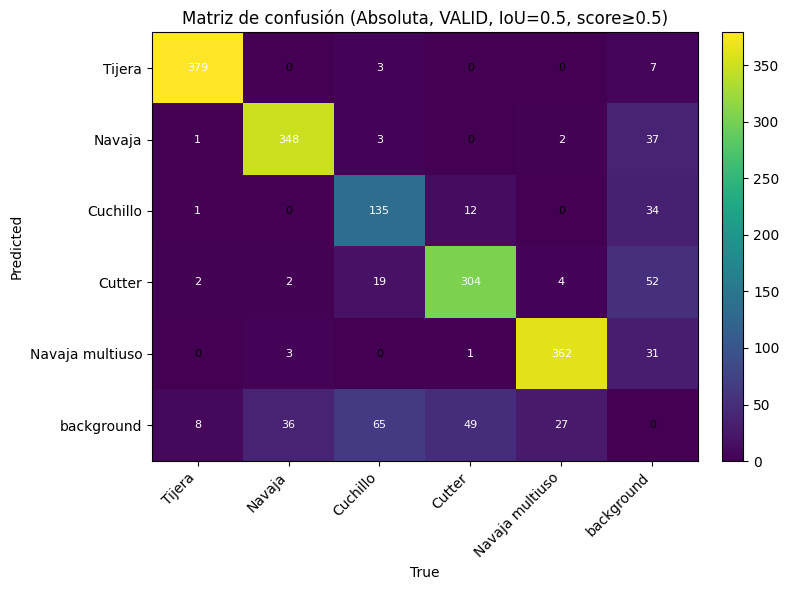

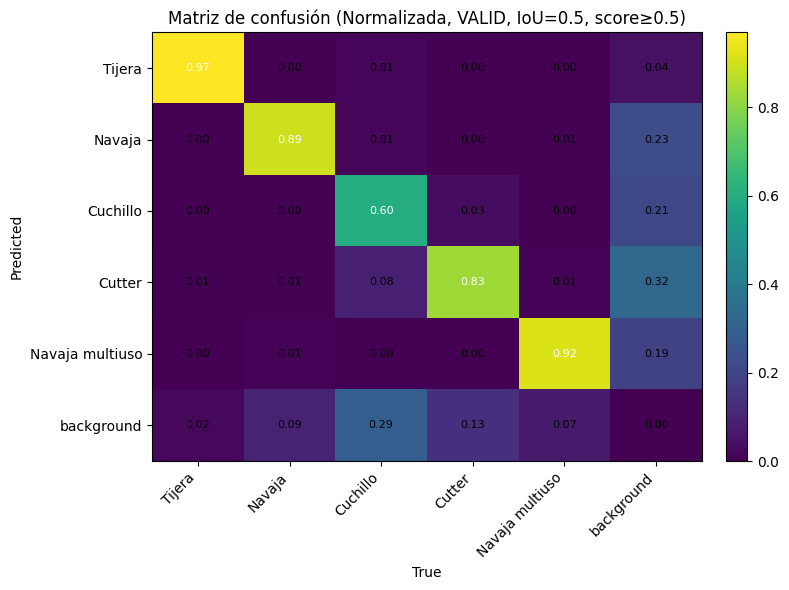

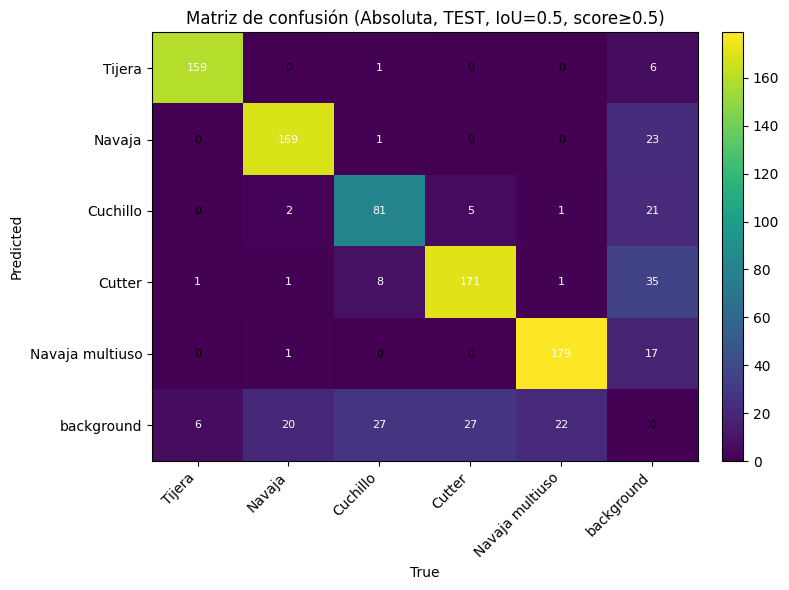

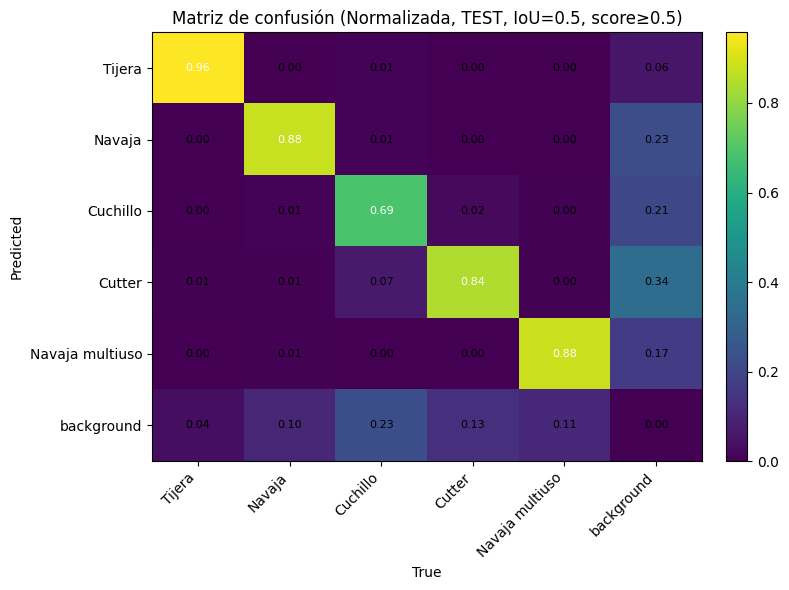

{'raw': array([[159,   0,   1,   0,   0,   6],
        [  0, 169,   1,   0,   0,  23],
        [  0,   2,  81,   5,   1,  21],
        [  1,   1,   8, 171,   1,  35],
        [  0,   1,   0,   0, 179,  17],
        [  6,  20,  27,  27,  22,   0]]),
 'norm': array([[0.95783133, 0.        , 0.00847458, 0.        , 0.        ,
         0.05882353],
        [0.        , 0.87564767, 0.00847458, 0.        , 0.        ,
         0.2254902 ],
        [0.        , 0.01036269, 0.68644068, 0.02463054, 0.00492611,
         0.20588235],
        [0.0060241 , 0.00518135, 0.06779661, 0.84236453, 0.00492611,
         0.34313725],
        [0.        , 0.00518135, 0.        , 0.        , 0.8817734 ,
         0.16666667],
        [0.03614458, 0.10362694, 0.22881356, 0.13300493, 0.10837438,
         0.        ]]),
 'labels': ['Tijera',
  'Navaja',
  'Cuchillo',
  'Cutter',
  'Navaja multiuso',
  'background']}

In [17]:
# ============================================================================================
# 12) Matriz de confusión (valid y test) para detección (IoU matching)
# ============================================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.ops import box_iou

def _greedy_match_iou(pred_boxes, gt_boxes, iou_thresh=0.5):
    """
    Empareja predicciones y GT por IoU máximo (greedy).
    Devuelve listas de índices emparejados: (pred_idx, gt_idx).
    """
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return []

    ious = box_iou(pred_boxes, gt_boxes).cpu().numpy()
    matches = []
    used_pred = set()
    used_gt = set()

    # Recorremos pares en orden de IoU decreciente
    flat = [ (i, j, ious[i, j]) for i in range(ious.shape[0]) for j in range(ious.shape[1]) ]
    flat.sort(key=lambda x: x[2], reverse=True)

    for i, j, v in flat:
        if v < iou_thresh:
            break
        if (i not in used_pred) and (j not in used_gt):
            used_pred.add(i); used_gt.add(j)
            matches.append((i, j))
    return matches

def confusion_matrix_detection(model, loader, class_names, score_thresh=0.5, iou_thresh=0.5, normalize=True, title="Confusion Matrix"):
    """
    Construye matriz de confusión (K+1)x(K+1) con 'background' como última clase.
    - Empareja por IoU (greedy).
    - Si clases difieren en un match, cuenta como pred=clase_pred, true=clase_gt.
    - Pred no emparejadas -> (pred=clase_pred, true=background).
    - GT no emparejadas   -> (pred=background, true=clase_gt).
    """
    model.eval()
    K = len(class_names)
    C = np.zeros((K+1, K+1), dtype=np.int64)  # filas=pred, cols=true ; ultimo índice = background
    bg = K  # índice background

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = [img.to(device) for img in imgs]
            outs = model(imgs)

            for out, tgt in zip(outs, targets):
                # Filtrar por score
                keep = out["scores"].cpu().numpy() >= score_thresh
                p_boxes = out["boxes"][keep].cpu()
                p_labels = out["labels"][keep].cpu().numpy()  # en 1..K

                g_boxes  = tgt["boxes"].cpu()
                g_labels = tgt["labels"].cpu().numpy()        # en 1..K

                # Emparejar por IoU (class-agnostic) para poder medir confusiones entre clases
                matches = _greedy_match_iou(p_boxes, g_boxes, iou_thresh=iou_thresh)
                matched_pred = set(i for i, _ in matches)
                matched_gt   = set(j for _, j in matches)

                # Contar matches (pueden ser aciertos o confusiones de clase)
                for i, j in matches:
                    pred_c = int(p_labels[i]) - 1  # a 0..K-1
                    true_c = int(g_labels[j]) - 1
                    C[pred_c, true_c] += 1

                # Predicciones no emparejadas -> true = background
                for i in range(len(p_boxes)):
                    if i not in matched_pred:
                        pred_c = int(p_labels[i]) - 1
                        C[pred_c, bg] += 1

                # GT no emparejadas -> pred = background
                for j in range(len(g_boxes)):
                    if j not in matched_gt:
                        true_c = int(g_labels[j]) - 1
                        C[bg, true_c] += 1

    # Normalización por columna (sum True) para leer "de lo verdadero, ¿qué predije?"
    Cn = C.astype(float)
    if normalize:
        col_sums = Cn.sum(axis=0, keepdims=True)
        col_sums[col_sums == 0] = 1.0
        Cn = Cn / col_sums

    # Plot
    labels_plot = class_names + ["background"]
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(Cn, interpolation='nearest', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_xticks(range(len(labels_plot)))
    ax.set_yticks(range(len(labels_plot)))
    ax.set_xticklabels(labels_plot, rotation=45, ha='right')
    ax.set_yticklabels(labels_plot)

    # Anotar valores
    for i in range(Cn.shape[0]):
        for j in range(Cn.shape[1]):
            val = Cn[i, j]
            txt = f"{val:.2f}" if normalize else str(C[i, j])
            ax.text(j, i, txt, ha='center', va='center', color='white' if val > 0.5 else 'black', fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return {"raw": C, "norm": Cn, "labels": labels_plot}

# ---- Ejecución: una matriz absoluta y normalizada para VALID y otra para TEST ----
confusion_matrix_detection(model, valid_dl, CLASS_NAMES, score_thresh=0.5, iou_thresh=0.5,
                           normalize=False, title="Matriz de confusión (Absoluta, VALID, IoU=0.5, score≥0.5)")
confusion_matrix_detection(model, valid_dl, CLASS_NAMES, score_thresh=0.5, iou_thresh=0.5,
                           normalize=True, title="Matriz de confusión (Normalizada, VALID, IoU=0.5, score≥0.5)")
confusion_matrix_detection(model, test_dl,  CLASS_NAMES, score_thresh=0.5, iou_thresh=0.5,
                           normalize=False, title="Matriz de confusión (Absoluta, TEST, IoU=0.5, score≥0.5)")
confusion_matrix_detection(model, test_dl,  CLASS_NAMES, score_thresh=0.5, iou_thresh=0.5,
                           normalize=True, title="Matriz de confusión (Normalizada, TEST, IoU=0.5, score≥0.5)")
